In [1]:
import scanpy as sc
import decoupler as dc
import numpy as np
from sklearn.decomposition import PCA
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf


sys.path.append('../code')

import GCAHelperFunctions



/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/gca_concatenated_anndata_March19_2025.h5ad')

In [3]:
# # adata.obs = adata.obs.drop(columns = ['closest_GCA_celltype','cell_type_ontology_term_id'])

ct_df = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_celltype_metadata.csv')
filtered_df = ct_df.drop_duplicates(subset=['author_cell_type', 'closest_GCA_celltype'])
ct_df = filtered_df.drop_duplicates(subset='author_cell_type', keep='first').reset_index(drop=True)

ct_df.drop(columns=['worksheet','column_4'],inplace=True)

adata.obs = adata.obs.merge(
    ct_df,
    left_on='author_cell_type', right_on='author_cell_type', how='left'
).set_index(adata.obs.index)

adata.obs['closest_GCA_celltype'].value_counts()

closest_GCA_celltype
Fibroblasts                 268391
Enterocytes                 215784
unknown                     173064
Plasma Cells                165670
Epithelial                  118472
                             ...  
Effector/Memory T Cells         26
Pericytes Secretory             23
Neurons Excitory                 1
Granulocytes Eosinophils         1
CD8 Memory                       1
Name: count, Length: 125, dtype: int64

In [4]:
adata.obs[['dataset_id','closest_GCA_celltype']][adata.obs['closest_GCA_celltype'].isna()]['dataset_id'].value_counts()

# Missing celltype-barcode matches for Krzak & Drokhylansky. Karakasheva, Burclaff, Maddipatla, Hickey, Zheng, nan all have unknown problems

dataset_id
Krzak2023              242191
nan                    213403
AgaceHelmsley3         138722
multiome                84213
snRNAseq                57015
DominguezUnpub          39111
AgaceHelmsley2          32263
Burclaff2022            12559
Maddipatla2023          10201
Drokhylansky2020         7180
Zheng2024                3096
AgaceHelmsley1           2474
KarakashevaHelmlsey      1518
Luoma2020                1061
Huang2019                   0
Parikh2019                  0
ArendsHelmsley              0
BasuGCARNA                  0
Dominguez2022               0
Yu2021                      0
Wang2020                    0
Uzzan2022                   0
Smillie2019                 0
Martin2019                  0
Jaeger2021                  0
Egozi2023                   0
Lee2020                     0
Elmentaite2020              0
Kong2023                    0
He2020                      0
James2020                   0
Kinchen2018                 0
Name: count, dtype: int64

In [5]:
adata.obs[['dataset_id','author_cell_type']][adata.obs['author_cell_type']=='nan']['dataset_id'].value_counts()

dataset_id
AgaceHelmsley3         138722
nan                     52912
AgaceHelmsley2          32263
Maddipatla2023          10201
Drokhylansky2020         7180
AgaceHelmsley1           2474
Zheng2024                   0
Yu2021                      0
Wang2020                    0
Krzak2023                   0
Uzzan2022                   0
Smillie2019                 0
Parikh2019                  0
Martin2019                  0
multiome                    0
Luoma2020                   0
Lee2020                     0
Kinchen2018                 0
Kong2023                    0
KarakashevaHelmlsey         0
James2020                   0
Jaeger2021                  0
Huang2019                   0
He2020                      0
Elmentaite2020              0
Egozi2023                   0
DominguezUnpub              0
Dominguez2022               0
Burclaff2022                0
BasuGCARNA                  0
ArendsHelmsley              0
snRNAseq                    0
Name: count, dtype: int64

## Add celltype hierarchy levels to dataframe, so we can do multi-resolution analysis

In [6]:
gca_tax = pd.read_csv('../data/gca_celltype_taxonomy.csv')

gca_tax = gca_tax.dropna(subset=['closest_GCA_celltype'])

set(adata.obs['closest_GCA_celltype']) - set(gca_tax['closest_GCA_celltype']) 

{'CD4+ T-Cells',
 'CD8 GammaDelta',
 'CD8 MAIT',
 'CD8 NK T',
 'CD8+ T-Cells',
 'Cycling T Cells',
 'DC Monocyte derived dendritic cell',
 'DC pDC',
 'Dendritic Cells',
 'Effector/Memory T Cells',
 'Enterochromaffin Cells',
 'Germinal Center B Cells (GC)',
 'IEL',
 'ILC NK Cells',
 'Interstitial Cells of Cajal (ICC)',
 'MAIT',
 'Mast Cells',
 'Memory B Cells',
 'Myofibroblasts',
 'Naive B-Cells',
 'Secretory Goblet cells Mature ',
 'T Cycling ',
 'TRM',
 'Tfh',
 'Th1',
 'Th17',
 'Treg',
 nan,
 'th1',
 'unknown'}

In [7]:
update_dict = {
    'T Cycling ': 'T Cycling',
    'Cycling T Cells': 'T Cycling',
    'CD4+ T-Cells': 'CD4 T',
    'CD8 GammaDelta': 'T GammaDelta',
    'CD8 MAIT': 'T MAIT',
    'CD8 NK T': 'NKT',
    'CD8+ T-Cells': 'CD8 T',
    'DC Monocyte derived dendritic cell': 'DC Monocyte derived dendritic cell (MO DC)',
    'Germinal Center B Cells (GC)': 'GC B Germinal Center',
    'Treg': 'CD4 Treg',
    'Dendritic Cells': 'Dendritic Cells (DC)',
    'Effector/Memory T Cells': 'CD8 Effector/Memory',
    'Enterochromaffin Cells': 'EEC Enterochromaffin Cells',
    'Germinal Center B Cells': 'GC B Germinal Center',
    'IEL': 'CD8 IEL',
    'ILC NK Cells': 'NK Cells',
    'Interstitial Cells of Cajal (ICC)': 'Fibroblasts Interstitial Cells of Cajal (ICC)',
    'MAIT': 'T MAIT',
    'Mast Cells': 'Granulocytes Mast Cells',
    'Memory B Cells': 'B Memory',
    'Myofibroblasts': 'Fibroblasts Myofibroblasts',
    'Naive B-Cells': 'B Naive',
    'TRM':'CD8 TRM',
    'Tfh': 'CD4 Tfh',
    'Th1': 'CD4 Th1',
    'Th17': 'CD4 Th17',
    'th1': 'CD4 Th1',
    'Secretory Goblet cells Mature ': 'Secretory Goblet cells Mature',
    'Myofibroblasts': 'Fibroblasts Myofibroblasts',
    'CD8 GammaDelta': 'T GammaDelta',
    'CD8 MAIT': 'T MAIT',
    'CD8 NK T': 'NKT',
    'DC pDC': 'pDC',
    'ILC NK Cells': 'NK Cells',
}

adata.obs['closest_GCA_celltype'] = adata.obs['closest_GCA_celltype'].replace(update_dict)


In [8]:
adata.obs['closest_GCA_celltype']

Dominguez2022_Pan_T7935490_AAACCTGCAAATTGCC                   CD4 Th1
Dominguez2022_Pan_T7935490_AAACGGGCATCTGGTA                   CD8 TRM
Dominguez2022_Pan_T7935490_AAACGGGTCTTGCATT                   CD8 TRM
Dominguez2022_Pan_T7935490_AAAGCAATCATCGCTC                   CD8 TRM
Dominguez2022_Pan_T7935490_AAAGTAGCAGTCACTA              T GammaDelta
                                                        ...          
Drokhylansky2020_H4_S24.TTTGTCAGTCAGTGGA       SMC Inner Muscle Cells
Drokhylansky2020_H4_S24.TTTGTCAGTTACAGAA       SMC Inner Muscle Cells
Drokhylansky2020_H4_S24.TTTGTCAGTTAGAACA                         Glia
Drokhylansky2020_H4_S24.TTTGTCATCCCTCTTT       SMC Inner Muscle Cells
Drokhylansky2020_H4_S24.TTTGTCATCCGCAAGC        Endothelial Lymphatic
Name: closest_GCA_celltype, Length: 3381939, dtype: object

In [9]:
nan_count = gca_tax['closest_GCA_celltype'].isna().sum()
print("Number of NaN values in 'closest_GCA_celltype':", nan_count)

Number of NaN values in 'closest_GCA_celltype': 0


In [10]:
print("Unique CellID in adata.obs:", adata.obs.index.is_unique)


Unique CellID in adata.obs: True


In [11]:

adata.obs = adata.obs.reset_index(names='CellID').merge(gca_tax, 
                                            left_on = 'closest_GCA_celltype', 
                                            right_on= 'closest_GCA_celltype', 
                                            how = 'left').set_index("CellID")



## Using PCA to understand variance in our data - whole dataset

In [ ]:
%%time

sc.pp.normalize_total(adata)

sc.pp.log1p(adata)

# sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# # Subset to HVG
# adata = adata[:, adata.var.highly_variable]

# # Perform PCA 
# sc.tl.pca(adata, n_comps=10, svd_solver='arpack')



In [54]:
%%time

# Extract PCA info
pca_df = pd.DataFrame(
    adata.obsm['X_pca'][:, :10], 
    columns=[f'PC{i+1}' for i in range(10)]
)

# Combine with metadata:
metadata = adata.obs.reset_index(drop=True)
data_for_model = pd.concat([pca_df.reset_index(drop=True), metadata], axis=1)

CPU times: user 127 ms, sys: 86.5 ms, total: 214 ms
Wall time: 231 ms


In [55]:
metadata

,sample_id,author_cell_type,donor_id,dataset_id,tissue_ontology_term,tissue_ontology_term_id,tissue_free_text,sample_source,sample_collection_method,tissue_type,...,gene_annotation_version,comments,description,publication_doi,protocol_url,total_counts,closest_GCA_celltype,cell_type_ontology_term_id,worksheet,column_4
0,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,organ_donor,surgical_resection,tissue,...,v98,nan,nan,10.1126/science.abl5197,nan,6260.0,unknown,NaN,Luoma2020_HCA_tier,NaN
1,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,organ_donor,surgical_resection,tissue,...,v98,nan,nan,10.1126/science.abl5197,nan,5592.0,unknown,NaN,Luoma2020_HCA_tier,NaN
2,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,organ_donor,surgical_resection,tissue,...,v98,nan,nan,10.1126/science.abl5197,nan,6916.0,unknown,NaN,Luoma2020_HCA_tier,NaN
3,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,organ_donor,surgical_resection,tissue,...,v98,nan,nan,10.1126/science.abl5197,nan,3465.0,unknown,NaN,Luoma2020_HCA_tier,NaN
4,Pan_T7935490,unknown,A29_390C,Dominguez2022,ileum,UBERON:0002116,nan,organ_donor,surgical_resection,tissue,...,v98,nan,nan,10.1126/science.abl5197,nan,6306.0,unknown,NaN,Luoma2020_HCA_tier,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381934,H4_S24,nan,H4,Drokhylansky2020,descending_colon,nan,Submucosa/Mucosa,surgical_donor,surgical_resection,tissue,...,nan,nan,nan,nan,nan,4302.0,NaN,NaN,NaN,NaN
3381935,H4_S24,nan,H4,Drokhylansky2020,descending_colon,nan,Submucosa/Mucosa,surgical_donor,surgical_resection,tissue,...,nan,nan,nan,nan,nan,8854.0,NaN,NaN,NaN,NaN
3381936,H4_S24,nan,H4,Drokhylansky2020,descending_colon,nan,Submucosa/Mucosa,surgical_donor,surgical_resection,tissue,...,nan,nan,nan,nan,nan,2799.0,NaN,NaN,NaN,NaN
3381937,H4_S24,nan,H4,Drokhylansky2020,descending_colon,nan,Submucosa/Mucosa,surgical_donor,surgical_resection,tissue,...,nan,nan,nan,nan,nan,5378.0,NaN,NaN,NaN,NaN


In [56]:
data_for_model

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,gene_annotation_version,comments,description,publication_doi,protocol_url,total_counts,closest_GCA_celltype,cell_type_ontology_term_id,worksheet,column_4
0,-0.987465,0.725354,-0.023365,-0.040800,0.216247,-0.068360,-0.797017,0.753765,-0.236857,-0.747713,...,v98,nan,nan,10.1126/science.abl5197,nan,6260.0,unknown,NaN,Luoma2020_HCA_tier,NaN
1,-1.139802,1.016719,-0.003449,0.071432,0.284444,-0.181319,-1.142983,0.817215,-0.098539,-0.842554,...,v98,nan,nan,10.1126/science.abl5197,nan,5592.0,unknown,NaN,Luoma2020_HCA_tier,NaN
2,-1.004660,0.643727,0.032793,-0.149594,0.147320,-0.104250,-0.676637,0.627654,-0.331262,-0.789229,...,v98,nan,nan,10.1126/science.abl5197,nan,6916.0,unknown,NaN,Luoma2020_HCA_tier,NaN
3,-1.249995,1.346809,-0.020513,0.092432,0.212274,-0.369849,-1.092022,0.469236,-0.009981,-0.736373,...,v98,nan,nan,10.1126/science.abl5197,nan,3465.0,unknown,NaN,Luoma2020_HCA_tier,NaN
4,-1.493031,1.972031,-0.003070,0.355131,0.190513,-0.374256,-1.541734,0.661411,0.106090,-0.996731,...,v98,nan,nan,10.1126/science.abl5197,nan,6306.0,unknown,NaN,Luoma2020_HCA_tier,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381934,9.501005,-0.925129,12.442074,1.336266,0.254475,-0.569524,0.150316,-0.631495,0.159099,0.666868,...,nan,nan,nan,nan,nan,4302.0,NaN,NaN,NaN,NaN
3381935,8.060275,-1.388478,13.374775,1.065952,0.196546,-0.422346,0.225381,-0.785043,0.023998,0.472633,...,nan,nan,nan,nan,nan,8854.0,NaN,NaN,NaN,NaN
3381936,6.100171,-1.091779,8.263479,0.564473,0.201407,-0.081691,-0.093051,-0.108070,0.030174,0.014683,...,nan,nan,nan,nan,nan,2799.0,NaN,NaN,NaN,NaN
3381937,8.408970,-1.364291,13.817767,1.237760,0.511710,-0.721269,0.189609,-0.651004,0.066237,0.527588,...,nan,nan,nan,nan,nan,5378.0,NaN,NaN,NaN,NaN


## PVCA for partitioning sources of variance in GCA

In [57]:
#source:
#https://www.niehs.nih.gov/research/resources/software/biostatistics/pvca

range(9)

range(0, 9)

In [58]:
adata.obs['alignment_software'].value_counts()

alignment_software
CellRanger_v3.0.2                                                  860336
cellranger_8.0.0                                                   734395
nan                                                                453481
cellranger_7.0.0                                                   280111
starsolo_2.7.10a                                                   275572
cellranger_4.0.0                                                   148082
cellranger 7.0.1                                                   127257
STARsolo_2.7.10a_alpha_220818                                       91406
cellranger_2.2                                                      89849
scRNA-seq: Cell Ranger (v3.0.2); scTCR-se: Cell Ranger (v3.1.0)     87845
cell_ranger_3.1.0                                                   61598
cellranger_6.1.1                                                    40901
CellRanger                                                          37174
STAR               

In [32]:
%%time
!mkdir ~/Projects/GCA/PVCA/

covariates = ['dataset_id', 'donor_id', 'sample_id', 'alignment_software', 'manner_of_death',              
              'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
              'sample_preservation_method', 'suspension_type', 'age_range']

celltype_covariates = ['closest_GCA_celltype', 'Lineage', 'Differentia', 'Habitus', 'Status', 'Whim']

# Idea number 1:
# Remove all cells which don't have complete metadata for all covariates being analyzed. 
data_clean = data_for_model.dropna(subset=covariates)



mkdir: /Users/kylekimler/Projects/GCA/PVCA/: File exists


NameError: name 'data_for_model' is not defined

In [60]:
data_clean['age_range'].value_counts()

# adata.obs['closest_GCA_celltype'].value_counts()

age_range
50-59      591590
unknown    545523
70-79      400297
nan        356755
60-69      333804
30-39      227551
40-49      216470
20-29      182543
80-89      176999
0-9        164273
10-19      145824
1-5         14215
5-15        12309
Other       11596
90-99        2190
Name: count, dtype: int64

In [61]:

covariates = ['dataset_id', 'donor_id', 'sample_id', 'alignment_software', 'manner_of_death',              
              'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
              'sample_preservation_method', 'suspension_type', 'age_range']

# Ensure data has no missing values across covariates:
data_clean = data_for_model.dropna(subset=covariates)

# Ensure no covariate has only one level (which statsmodels can't handle):
valid_covariates = [cov for cov in covariates if data_clean[cov].nunique() > 1]

var_explained = pd.DataFrame(index=covariates + ['residual'])


In [62]:
for cov in covariates:
    counts = data_clean[cov].value_counts()
    print(f"{cov}: {counts.min()} cells per smallest category, {counts.size} categories.")


dataset_id: 1790 cells per smallest category, 32 categories.
donor_id: 54 cells per smallest category, 383 categories.
sample_id: 2 cells per smallest category, 863 categories.
alignment_software: 14675 cells per smallest category, 17 categories.
manner_of_death: 12590 cells per smallest category, 5 categories.
radial_tissue_term: 58288 cells per smallest category, 11 categories.
tissue_ontology_term: 1545 cells per smallest category, 14 categories.
sample_collection_method: 213403 cells per smallest category, 3 categories.
sampled_site_condition: 74510 cells per smallest category, 5 categories.
sample_preservation_method: 229380 cells per smallest category, 3 categories.
suspension_type: 213403 cells per smallest category, 3 categories.
age_range: 2190 cells per smallest category, 15 categories.


In [65]:
%%time
pcs = list(range(1,11))
print(f'PC{pcs}')
# Are covariates even associated with PCs at all? Let's use a simple model to find out
ols_results = []

pcs = [f'PC{i+1}' for i in range(10)]

import statsmodels.api as sm
import statsmodels.formula.api as smf


for cov in covariates:
    for pc in pcs:
        print('building model for',cov,pc)
        formula = f"{pc} ~ C({cov})"
        ols_model = smf.ols(formula, data=data_clean).fit()
        ols_results.append({
            'covariate': cov,
            'PC': pc,
            'R_squared': ols_model.rsquared,
            'p_value': ols_model.f_pvalue
        })



PC[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
building model for dataset_id PC1
building model for dataset_id PC2
building model for dataset_id PC3
building model for dataset_id PC4
building model for dataset_id PC5
building model for dataset_id PC6
building model for dataset_id PC7
building model for dataset_id PC8
building model for dataset_id PC9
building model for dataset_id PC10
building model for donor_id PC1
building model for donor_id PC2
building model for donor_id PC3
building model for donor_id PC4
building model for donor_id PC5
building model for donor_id PC6
building model for donor_id PC7
building model for donor_id PC8
building model for donor_id PC9
building model for donor_id PC10
building model for sample_id PC1
building model for sample_id PC2
building model for sample_id PC3
building model for sample_id PC4
building model for sample_id PC5
building model for sample_id PC6
building model for sample_id PC7
building model for sample_id PC8
building model for sample_id PC9
buildin

AttributeError: 'list' object has no attribute 'head'

In [69]:


# Convert list of OLS results to a DataFrame for var explained plotting
ols_df = pd.DataFrame(ols_results)

# Compute mean variance explained per covariate
var_explained_df = ols_df.groupby("covariate")["R_squared"].mean().reset_index()
var_explained_df.columns = ["covariate", "mean_variance_explained"]

var_explained_df = var_explained_df.sort_values("mean_variance_explained", ascending=False)

var_explained_df.to_csv('~/Projects/GCA/PVCA/OLS_pvca_per_covariate_robust.csv')


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_41455/1015100650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=var_explained_df, x="mean_variance_explained", y="covariate", palette="viridis")


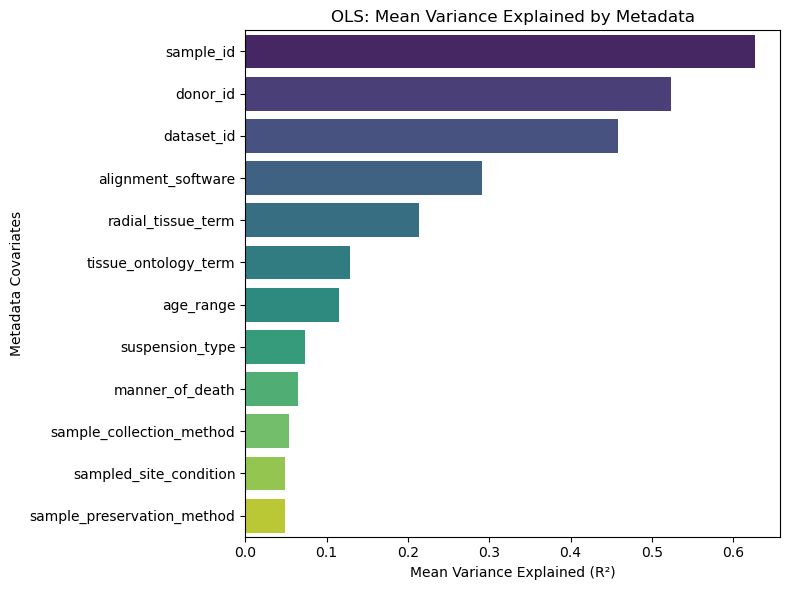

In [70]:
# var explaiend graph
plt.figure(figsize=(8, 6))
sns.barplot(data=var_explained_df, x="mean_variance_explained", y="covariate", palette="viridis")

plt.xlabel("Mean Variance Explained (R²)")
plt.ylabel("Metadata Covariates")
plt.title("OLS: Mean Variance Explained by Metadata")

plt.tight_layout()
plt.show()

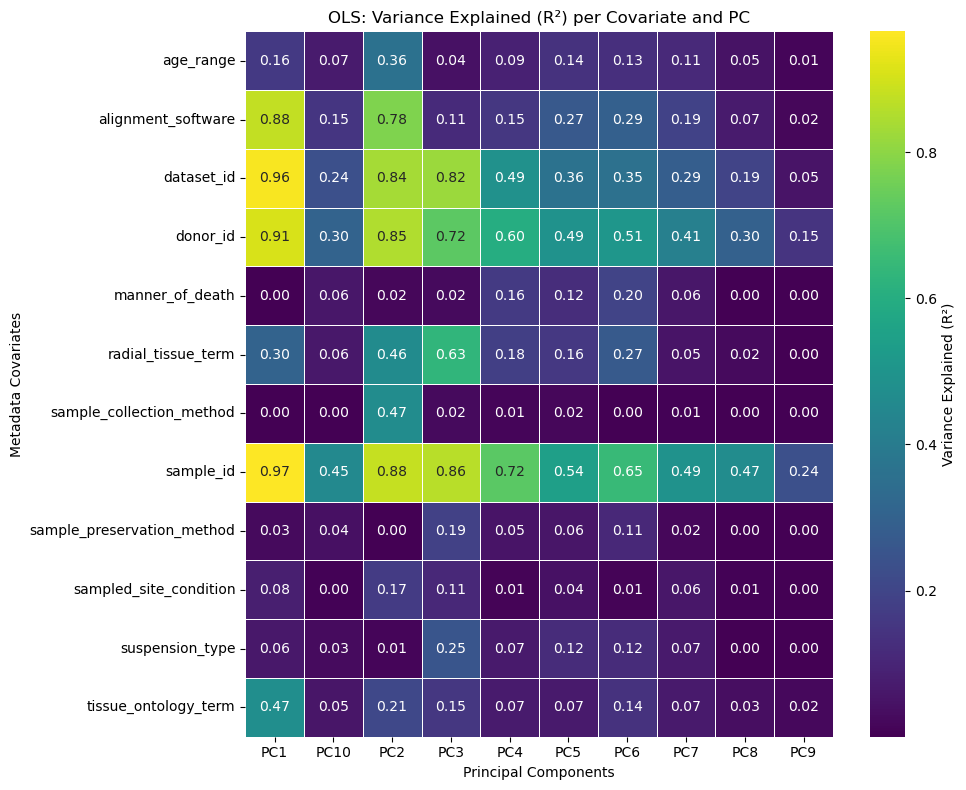

CPU times: user 188 ms, sys: 12.4 ms, total: 201 ms
Wall time: 202 ms


In [76]:
%%time 
# Heatmap of OLS results
heatmap_df = pd.pivot_table(ols_df, values = 'R_squared', index='covariate', columns='PC')

# Plotting a tidy heatmap:
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_df, cmap='viridis', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Variance Explained (R²)'}
)

plt.title('OLS: Variance Explained (R²) per Covariate and PC')
plt.xlabel('Principal Components')
plt.ylabel('Metadata Covariates')

plt.tight_layout()
plt.show()

In [78]:
ols_df.to_csv('~/Projects/GCA/PVCA/PVCA_10pcs_results_dataframe.csv')


## OLS PVCA per Celltype

In [12]:
# Normalize and log1p whole dataset before subsetting

sc.pp.normalize_total(adata)

sc.pp.log1p(adata)


In [15]:
adata.obs['Lineage'].unique()[[0,2,3,4]]


array(['Immune', 'Epithelial', 'Stromal', 'Neurons'], dtype=object)

In [13]:

covariates = ['dataset_id', 'donor_id', 'sample_id', 'alignment_software', 'manner_of_death',              
              'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
              'sample_preservation_method', 'suspension_type', 'age_range']

celltype_covariates = ['closest_GCA_celltype', 'Lineage', 'Differentia', 'Habitus', 'Status', 'Whim']


In [18]:
%%time
for lineage in adata.obs['Lineage'].unique()[[0,2,3,4]]:
    adata_subset = adata[adata.obs['Lineage'] == lineage].copy()
    # Identify highly variable genes
    sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
    # Subset to highly variable genes
    adata_subset = adata_subset[:, adata_subset.var.highly_variable].copy()
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=10, svd_solver='arpack')
    # Extract principal components
    pca_df = pd.DataFrame(
        adata_subset.obsm['X_pca'][:, :10], 
        columns=[f'PC{i+1}' for i in range(10)]
    )
    # Combine with metadata:
    metadata = adata_subset.obs.reset_index(drop=True)
    data_for_model = pd.concat([pca_df.reset_index(drop=True), metadata], axis=1)
    covariates = ['dataset_id', 'donor_id', 'sample_id', 'alignment_software', 'manner_of_death',              
                  'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
                  'sample_preservation_method', 'suspension_type', 'age_range']
    # Ensure data has no missing values across covariates:
    data_clean = data_for_model.dropna(subset=covariates)
    # Ensure no covariate has only one level (which statsmodels can't handle):
    valid_covariates = [cov for cov in covariates if data_clean[cov].nunique() > 1]
    var_explained = pd.DataFrame(index=covariates + ['residual'])
    pcs = list(range(1,11))
    ols_results = []
    pcs = [f'PC{i+1}' for i in range(10)]
    for cov in covariates:
        for pc in pcs:
            print('building model for ',lineage,' ',cov,' ',pc)
            formula = f"{pc} ~ C({cov})"
            ols_model = smf.ols(formula, data=data_clean).fit()
            ols_results.append({
                'covariate': cov,
                'PC': pc,
                'R_squared': ols_model.rsquared,
                'p_value': ols_model.f_pvalue
            })
    # Convert list of OLS results to a DataFrame for var explained plotting
    ols_df = pd.DataFrame(ols_results)
    # Compute mean variance explained per covariate
    var_explained_df = ols_df.groupby("covariate")["R_squared"].mean().reset_index()
    var_explained_df.columns = ["covariate", "mean_variance_explained"]
    var_explained_df = var_explained_df.sort_values("mean_variance_explained", ascending=False)
    var_explained_df.to_csv(f'~/Projects/GCA/PVCA/{lineage}_OLS_pvca_per_covariate_robust.csv')
    heatmap_df = pd.pivot_table(ols_df, values = 'R_squared', index='covariate', columns='PC')
    heatmap_df.to_csv(f'~/Projects/GCA/PVCA/{lineage}_OLS_pvca_per_covariate_heatmap_data.csv')
    
    


    
    
        
        

building model for  Immune   dataset_id   PC1
building model for  Immune   dataset_id   PC2
building model for  Immune   dataset_id   PC3
building model for  Immune   dataset_id   PC4
building model for  Immune   dataset_id   PC5
building model for  Immune   dataset_id   PC6
building model for  Immune   dataset_id   PC7
building model for  Immune   dataset_id   PC8
building model for  Immune   dataset_id   PC9
building model for  Immune   dataset_id   PC10
building model for  Immune   donor_id   PC1
building model for  Immune   donor_id   PC2
building model for  Immune   donor_id   PC3
building model for  Immune   donor_id   PC4
building model for  Immune   donor_id   PC5
building model for  Immune   donor_id   PC6
building model for  Immune   donor_id   PC7
building model for  Immune   donor_id   PC8
building model for  Immune   donor_id   PC9
building model for  Immune   donor_id   PC10
building model for  Immune   sample_id   PC1
building model for  Immune   sample_id   PC2
building

In [23]:
celltypes = pd.Series(adata.obs['Differentia'].unique())


array(['Lymphoid', 'Myeloid', 'Transiently Amplifying Cells (TA)',
       'Colonocytes', 'Secretory', 'Epithelial Stem Cells (LGR5+)',
       'Fibroblasts', 'Pericytes', 'Glia', 'Enteroendocrine Cells (EEC)',
       'Endothelial', 'Enterocytes', 'Smooth Muscle Cells (SMC)',
       'Follicle associated enterocyte (FAE)',
       'Microfold Cells (M Cells)', 'Excitory', 'Mesothelial',
       'Adipocytes'], dtype=object)

In [24]:
%%time
for lineage in celltypes.dropna().values:
    adata_subset = adata[adata.obs['Differentia'] == lineage].copy()
    # Identify highly variable genes
    sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
    # Subset to highly variable genes
    adata_subset = adata_subset[:, adata_subset.var.highly_variable].copy()
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=10, svd_solver='arpack')
    # Extract principal components
    pca_df = pd.DataFrame(
        adata_subset.obsm['X_pca'][:, :10], 
        columns=[f'PC{i+1}' for i in range(10)]
    )
    # Combine with metadata:
    metadata = adata_subset.obs.reset_index(drop=True)
    data_for_model = pd.concat([pca_df.reset_index(drop=True), metadata], axis=1)
    covariates = ['dataset_id', 'donor_id', 'sample_id', 'alignment_software', 'manner_of_death',              
                  'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
                  'sample_preservation_method', 'suspension_type', 'age_range']
    # Ensure data has no missing values across covariates:
    data_clean = data_for_model.dropna(subset=covariates)
    # Ensure no covariate has only one level (which statsmodels can't handle):
    valid_covariates = [cov for cov in covariates if data_clean[cov].nunique() > 1]
    var_explained = pd.DataFrame(index=covariates + ['residual'])
    pcs = list(range(1,11))
    ols_results = []
    pcs = [f'PC{i+1}' for i in range(10)]
    for cov in covariates:
        for pc in pcs:
            print('building model for ',lineage,' ',cov,' ',pc)
            formula = f"{pc} ~ C({cov})"
            ols_model = smf.ols(formula, data=data_clean).fit()
            ols_results.append({
                'covariate': cov,
                'PC': pc,
                'R_squared': ols_model.rsquared,
                'p_value': ols_model.f_pvalue
            })
    # Convert list of OLS results to a DataFrame for var explained plotting
    ols_df = pd.DataFrame(ols_results)
    # Compute mean variance explained per covariate
    var_explained_df = ols_df.groupby("covariate")["R_squared"].mean().reset_index()
    var_explained_df.columns = ["covariate", "mean_variance_explained"]
    var_explained_df = var_explained_df.sort_values("mean_variance_explained", ascending=False)
    var_explained_df.to_csv(f'~/Projects/GCA/PVCA/{lineage}_OLS_pvca_per_covariate_robust.csv')
    heatmap_df = pd.pivot_table(ols_df, values = 'R_squared', index='covariate', columns='PC')
    heatmap_df.to_csv(f'~/Projects/GCA/PVCA/{lineage}_OLS_pvca_per_covariate_heatmap_data.csv')
    
    


    
    
        
        

building model for  Lymphoid   dataset_id   PC1
building model for  Lymphoid   dataset_id   PC2
building model for  Lymphoid   dataset_id   PC3
building model for  Lymphoid   dataset_id   PC4
building model for  Lymphoid   dataset_id   PC5
building model for  Lymphoid   dataset_id   PC6
building model for  Lymphoid   dataset_id   PC7
building model for  Lymphoid   dataset_id   PC8
building model for  Lymphoid   dataset_id   PC9
building model for  Lymphoid   dataset_id   PC10
building model for  Lymphoid   donor_id   PC1
building model for  Lymphoid   donor_id   PC2
building model for  Lymphoid   donor_id   PC3
building model for  Lymphoid   donor_id   PC4
building model for  Lymphoid   donor_id   PC5
building model for  Lymphoid   donor_id   PC6
building model for  Lymphoid   donor_id   PC7
building model for  Lymphoid   donor_id   PC8
building model for  Lymphoid   donor_id   PC9
building model for  Lymphoid   donor_id   PC10
building model for  Lymphoid   sample_id   PC1
building mo

/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)


IndexError: index -1 is out of bounds for axis 0 with size 0

In [38]:
# Plot the results

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']

## Correlating PCs and covariates per lineage

In [31]:
adata.obs['Lineage'].unique()[[0,2,3,4]]

array(['Immune', 'Epithelial', 'Stromal', 'Neurons'], dtype=object)

In [136]:
%%time

# Dictionary to store correlation results
corr_dict = {}

# Iterate over unique lineages
for lineage in adata.obs['Lineage'].unique()[[0,2,3,4]]:
    adata_subset = adata[adata.obs['Lineage'] == lineage].copy()
    # Identify highly variable genes
    sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
    # Subset to highly variable genes
    adata_subset = adata_subset[:, adata_subset.var.highly_variable].copy()
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=10, svd_solver='arpack')
    # Extract principal components
    pcs = pd.DataFrame(adata_subset.obsm['X_pca'], index=adata_subset.obs.index, columns=[f'PC{i+1}' for i in range(10)])
    # Extract metadata covariates and one-hot encode categorical variables
    metadata = pd.get_dummies(adata_subset.obs[covariates], drop_first=True, dtype=float)
    # Compute Pearson correlation and p-values
    corr_matrix = pd.DataFrame(index=pcs.columns, columns=metadata.columns)
    pval_matrix = pd.DataFrame(index=pcs.columns, columns=metadata.columns)
    for pc in pcs.columns:
        for covariate in metadata.columns:
            valid_idx = metadata[covariate].notna() & pcs[pc].notna()
            if valid_idx.sum() > 1:  # Ensure at least 2 valid values for Pearson
                corr, pval = stats.pearsonr(pcs.loc[valid_idx, pc], metadata.loc[valid_idx, covariate])
                corr_matrix.loc[pc, covariate] = corr
                pval_matrix.loc[pc, covariate] = pval
            else:
                corr_matrix.loc[pc, covariate] = np.nan
                pval_matrix.loc[pc, covariate] = np.nan
    # Store results
    corr_dict[lineage] = (corr_matrix.astype(float), pval_matrix.astype(float))



/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > numbe

CPU times: user 1h 9min 10s, sys: 1min 47s, total: 1h 10min 57s
Wall time: 1h 10min 31s


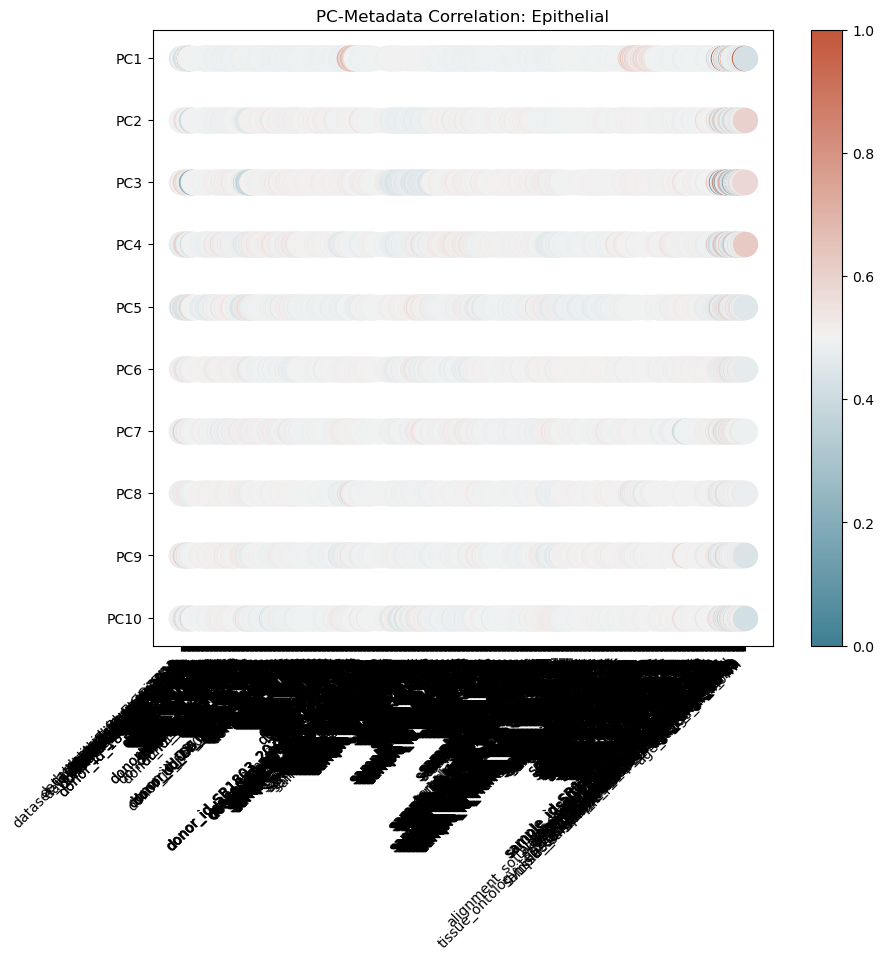

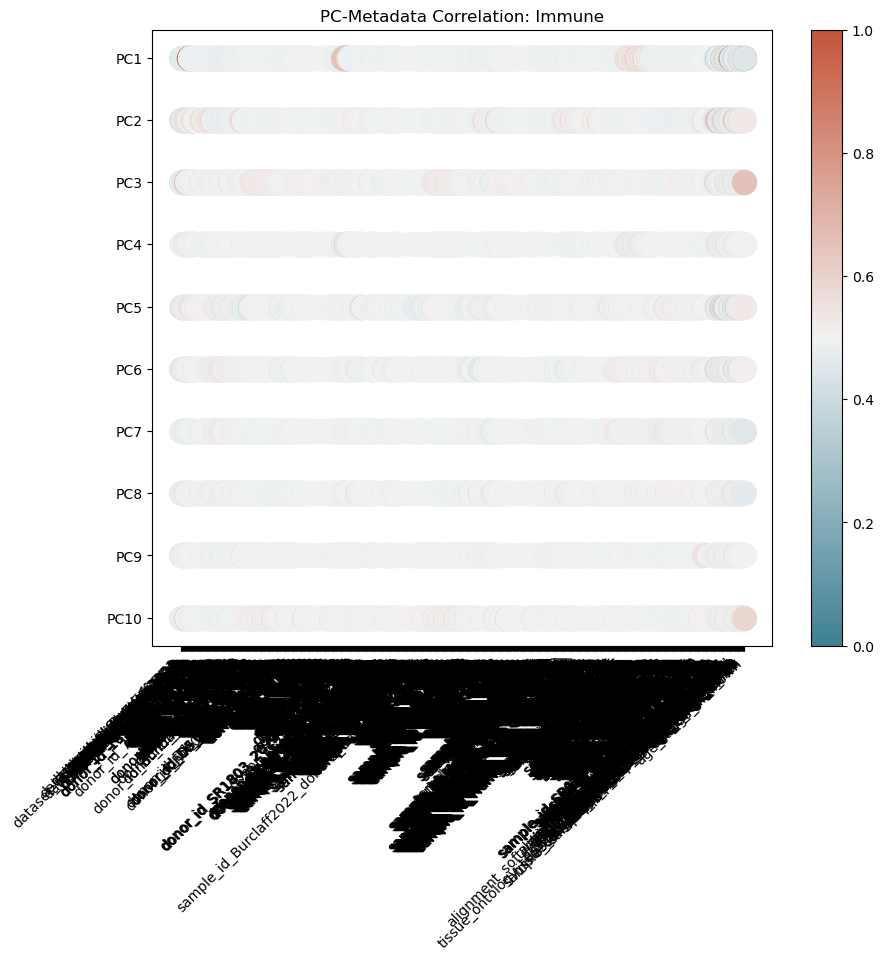

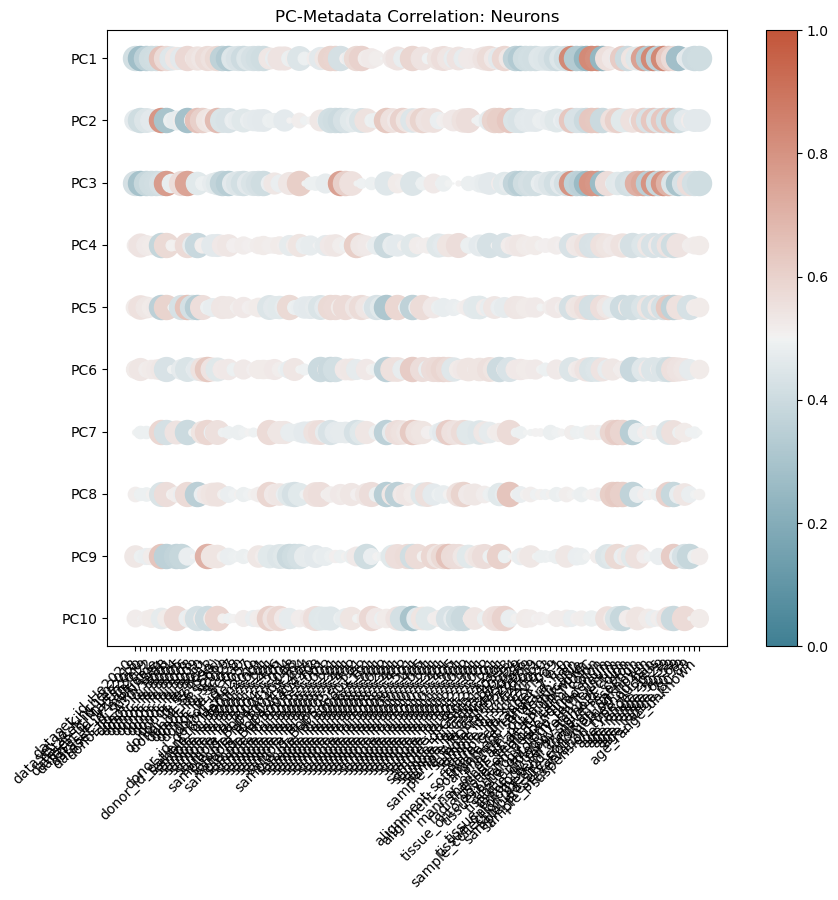

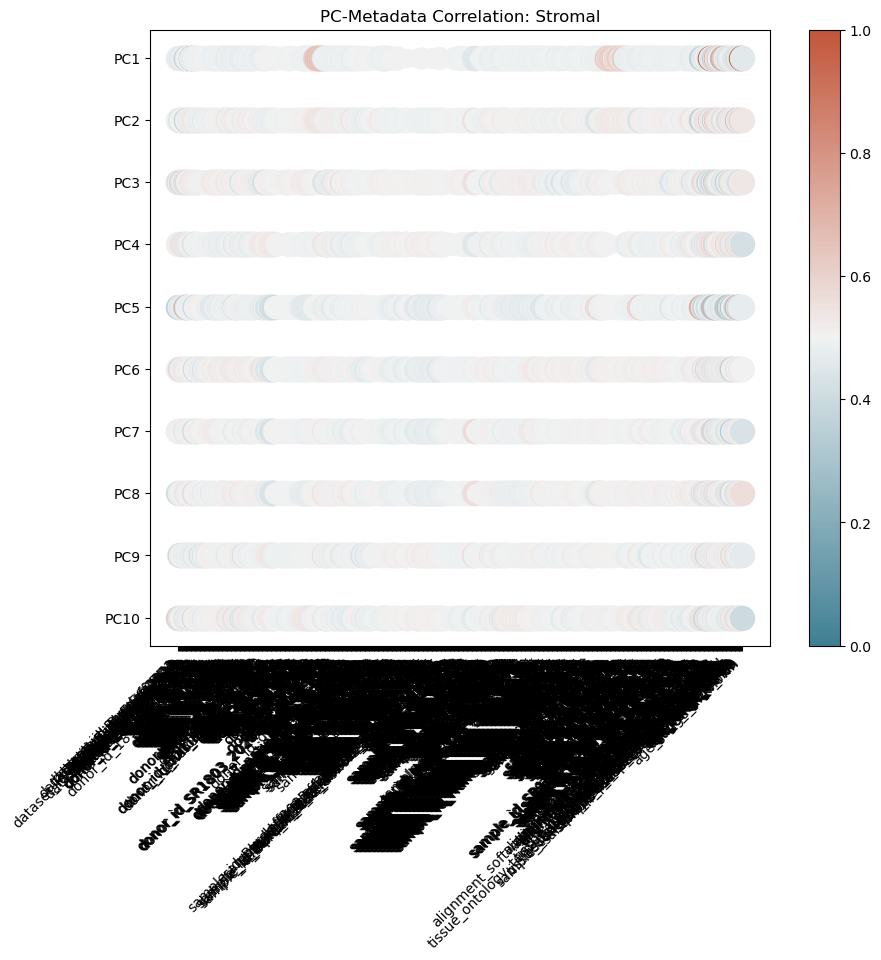

CPU times: user 3min 49s, sys: 3.05 s, total: 3min 52s
Wall time: 3min 53s


In [142]:
%%time 

# Create a heatmap function
def plot_corr_heatmap(corr_matrix, pval_matrix, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    # Define circle sizes based on p-values
    sizes = (1 - pval_matrix).values * 300
    # Define color based on correlation values
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    # Scatter plot with circles
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            plt.scatter(j, i, s=sizes[i, j], color=cmap((corr_matrix.iloc[i, j] + 1) / 2))
    # Customize the plot
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax)
    plt.show()

# Plot heatmaps for each lineage
for lineage, (corr_matrix, pval_matrix) in corr_dict.items():
    plot_corr_heatmap(corr_matrix, pval_matrix, title=f'PC-Metadata Correlation: {lineage}')


In [141]:
for lineage, (corr_matrix, pval_matrix) in corr_dict.items():
    corr_matrix.to_csv(f"corr_matrix_{lineage}.csv")
    pval_matrix.to_csv(f"pval_matrix_{lineage}.csv")

### per celltype

In [137]:
adata.obs['Differentia'].unique()

array([nan, 'Transiently Amplifying Cells (TA)', 'Colonocytes',
       'Secretory', 'Epithelial Stem Cells (LGR5+)', 'Myeloid',
       'Lymphoid', 'Pericytes', 'Glia', 'Enteroendocrine Cells (EEC)',
       'Fibroblasts', 'Endothelial', 'Enterocytes',
       'Smooth Muscle Cells (SMC)',
       'Follicle associated enterocyte (FAE)',
       'Microfold Cells (M Cells)', 'Excitory', 'Mesothelial'],
      dtype=object)

In [ ]:
%%time

# Dictionary to store correlation results
corr_dict = {}

# Iterate over unique lineages
for lineage in adata.obs['Lineage'].unique()[1:5]:
    adata_subset = adata[adata.obs['Lineage'] == lineage].copy()
    # Identify highly variable genes
    sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
    # Subset to highly variable genes
    adata_subset = adata_subset[:, adata_subset.var.highly_variable].copy()
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=10, svd_solver='arpack')
    # Extract principal components
    pcs = pd.DataFrame(adata_subset.obsm['X_pca'], index=adata_subset.obs.index, columns=[f'PC{i+1}' for i in range(10)])
    # Extract metadata covariates and one-hot encode categorical variables
    metadata = pd.get_dummies(adata_subset.obs[covariates], drop_first=True, dtype=float)
    # Compute Pearson correlation and p-values
    corr_matrix = pd.DataFrame(index=pcs.columns, columns=metadata.columns)
    pval_matrix = pd.DataFrame(index=pcs.columns, columns=metadata.columns)
    for pc in pcs.columns:
        for covariate in metadata.columns:
            valid_idx = metadata[covariate].notna() & pcs[pc].notna()
            if valid_idx.sum() > 1:  # Ensure at least 2 valid values for Pearson
                corr, pval = stats.pearsonr(pcs.loc[valid_idx, pc], metadata.loc[valid_idx, covariate])
                corr_matrix.loc[pc, covariate] = corr
                pval_matrix.loc[pc, covariate] = pval
            else:
                corr_matrix.loc[pc, covariate] = np.nan
                pval_matrix.loc[pc, covariate] = np.nan
    # Store results
    corr_dict[lineage] = (corr_matrix.astype(float), pval_matrix.astype(float))



In [142]:
# %%time
# # Mixed effects modeling didn't converge - is data too large? 
# for pc in [f'PC{i+1}' for i in range(10)]:
#     variance_per_covariate = {}
#     for cov in covariates:
#         if data_clean[cov].nunique() <= 1 or data_clean.groupby(cov, observed=True).size().min() < 2:
#             print(f"Covariate '{cov}' skipped for PC '{pc}' due to insufficient data.")
#             continue

#         try:
#             formula = f"{pc} ~ 1"
#             print('creating model for',pc,'modeling covariate:',cov)
#             model = smf.mixedlm(formula, data_clean, groups=data_clean[cov])
#             result = model.fit(reml=True, method='lbfgs')

#             group_var = result.cov_re.iloc[0, 0]
#             residual_var = result.scale
#             total_var = group_var + residual_var

#             frac_explained = group_var / total_var
#             variance = frac_explained

#         except Exception as e:
#             print(f"Covariate '{cov}' failed for PC '{pc}': {e}")
#             variance = np.nan

#         variance_entry = variance if not np.isnan(variance) else 0
#         variance_per_covariate[cov] = variance_entry

#     # After covariates, fit a simple intercept-only model for residual estimation:
#     model_resid = smf.ols(f"{pc} ~ 1", data_clean).fit()
#     residual_var = model_resid.mse_resid
#     total_var = model_resid.mse_total
#     variance_per_covariate['residual'] = residual_var / total_var

#     var_explained[pc] = pd.Series(variance_per_covariate)


creating model for PC1 modeling covariate: dataset_id
creating model for PC1 modeling covariate: donor_id
creating model for PC1 modeling covariate: sample_id
creating model for PC1 modeling covariate: alignment_software
creating model for PC1 modeling covariate: manner_of_death


/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


creating model for PC1 modeling covariate: radial_tissue_term
creating model for PC1 modeling covariate: tissue_ontology_term
creating model for PC1 modeling covariate: sample_collection_method


/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


creating model for PC1 modeling covariate: sampled_site_condition


...

creating model for PC8 modeling covariate: suspension_type


/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


creating model for PC8 modeling covariate: age_range


/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


CPU times: user 13min 40s, sys: 4min 25s, total: 18min 5s
Wall time: 2min 37s


In [143]:
# Mean variance explained clearly across PCs
var_explained['mean_variance_explained'] = var_explained.mean(axis=1)
var_explained.sort_values('mean_variance_explained', ascending=False, inplace=True)

var_explained.to_csv('~/Projects/GCA/PVCA/pvca_per_covariate_robust.csv')

In [152]:
var_explained

,covariate,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,mean_variance_explained
0,residual,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
1,dataset_id,0.874470,0.800000,0.800000,0.500000,0.500000,0.500000,0.5,0.500000,0.621809
2,sample_id,0.973075,0.800000,0.894359,0.559457,0.586359,0.582622,0.5,0.000000,0.611984
3,alignment_software,0.800000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.537500
4,manner_of_death,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000
5,radial_tissue_term,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000
6,tissue_ontology_term,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000
7,sample_collection_method,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000
8,sampled_site_condition,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000
9,sample_preservation_method,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.500000,0.500000


In [ ]:
# # var_explained.reset_index(names='covariate', inplace=True)
# plot_df = var_explained[var_explained['covariate'] != 'residual']

# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import matplotlib.colors as colors

# plot_df_sorted = plot_df.sort_values('mean_variance_explained', ascending=False)

# norm = colors.Normalize(plot_df_sorted['mean_variance_explained'].min(), 
#                         plot_df_sorted['mean_variance_explained'].max())
# cmap = cm.viridis

# plt.figure(figsize=(8, 6))
# sns.barplot(
#     data=plot_df_sorted,
#     x='mean_variance_explained', y='covariate',
#     palette=[cmap(norm(x)) for x in plot_df_sorted['mean_variance_explained']]
# )

# plt.xlabel('Mean Variance Explained')
# plt.ylabel('Covariate')
# plt.title('PVCA: Variance Explained by Metadata (Continuous)')
# plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), label='Variance Explained')

# plt.tight_layout()
# plt.show()
